In [1]:
!pip install librosa

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   -------------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
pip install pydub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import cv2
import librosa

In [2]:
import os

labels = {}

for idx, folder in enumerate(os.listdir('augmented_dataset/augmented_dataset/')):
    labels[folder] = idx

print(labels)

{'bed': 0, 'bird': 1, 'cat': 2, 'dog': 3, 'down': 4, 'eight': 5, 'five': 6, 'four': 7, 'go': 8, 'happy': 9, 'house': 10, 'left': 11, 'marvel': 12, 'nine': 13, 'no': 14, 'off': 15, 'on': 16, 'one': 17, 'right': 18, 'seven': 19, 'sheila': 20, 'six': 21, 'stop': 22, 'three': 23, 'tree': 24, 'two': 25, 'up': 26, 'wow': 27, 'yes': 28, 'zero': 29}


In [3]:
MAX_LEN = 128

def pad_spectrogram(spec):

    if spec.shape[1] < MAX_LEN:
        pad_width = MAX_LEN - spec.shape[1]
        spec = np.pad(spec, ((0,0),(0,pad_width)))

    else:
        spec = spec[:, :MAX_LEN]

    return spec

In [4]:
X_aranc_axmuki = []
y_aranc_axmuki = []
for i in os.listdir('augmented_dataset/augmented_dataset/'):
    for j in os.listdir(f'augmented_dataset/augmented_dataset/{i}/'):
        try:
            audio_path = f'augmented_dataset/augmented_dataset/{i}/{j}'
            signal, sr = librosa.load(audio_path, sr=16000)
            
            mel_spec = librosa.feature.melspectrogram(
                y=signal,
                sr=sr,
                n_mels=128,
                hop_length=512,
                n_fft=2048
            )
            
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
            voice_array = pad_spectrogram(mel_spec_db)
            voice_array = voice_array.reshape(128, 128, 1)
            X_aranc_axmuki.append(voice_array)
            y_aranc_axmuki.append(labels[i])
        except:
            continue
X_aranc_axmuki = np.array(X_aranc_axmuki)
y_aranc_axmuki = np.array(y_aranc_axmuki)

In [5]:
X_axmukov = []
y_axmuko = []
for i in os.listdir('augmented_dataset_verynoisy/augmented_dataset_verynoisy/'):
    for j in os.listdir(f'augmented_dataset_verynoisy/augmented_dataset_verynoisy/{i}/'):
        try:
            audio_path = f'augmented_dataset_verynoisy/augmented_dataset_verynoisy/{i}/{j}'
            signal, sr = librosa.load(audio_path, sr=16000)
            
            mel_spec = librosa.feature.melspectrogram(
                y=signal,
                sr=sr,
                n_mels=128,
                hop_length=512,
                n_fft=2048
            )
            
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
            voice_array = pad_spectrogram(mel_spec_db)
            voice_array = voice_array.reshape(128, 128, 1)
            X_axmukov.append(voice_array)
            y_axmuko.append(labels[i])
        except:
            continue
X_axmukov = np.array(X_axmukov)
y_axmuko = np.array(y_axmuko)

C:\Users\USER\AppData\Local\Temp\ipykernel_18852\4206566925.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(audio_path, sr=16000)
C:\Users\USER\Desktop\ML jupyter\venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [6]:
X_train = np.concatenate((X_aranc_axmuki, X_axmukov), axis=0)
y_train = np.concatenate((y_aranc_axmuki, y_axmuko), axis=0)

In [7]:
X_train.shape

(83698, 128, 128, 1)

In [8]:
y_train.shape

(83698,)

Text(0.5, 1.0, '9')

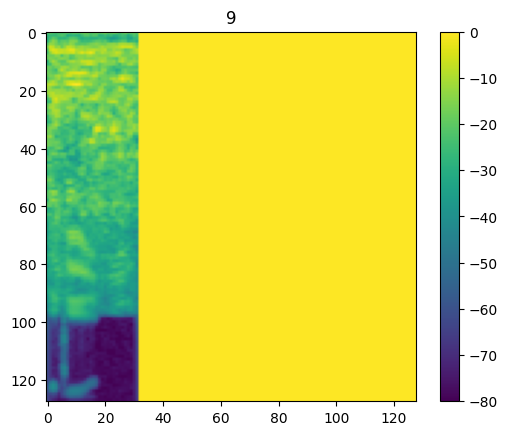

In [9]:
import random

idx = random.randint(0, len(X_train)-1)

plt.imshow(X_train[idx][:,:,0])
plt.colorbar()
plt.title(y_train[idx])

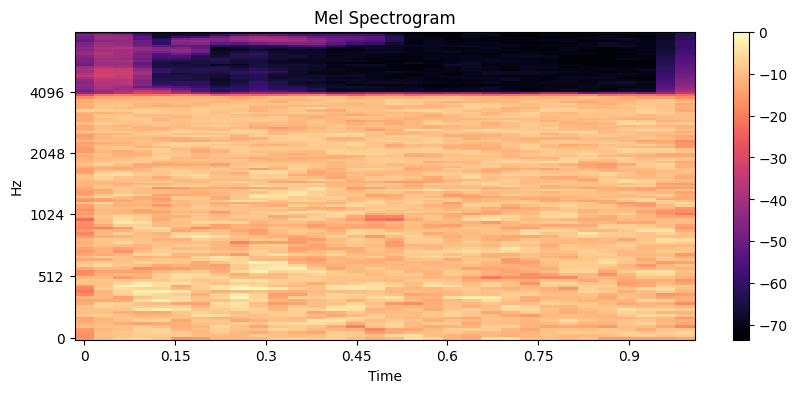

In [10]:
plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='mel'
)

plt.title("Mel Spectrogram")
plt.colorbar()
plt.show()

In [11]:
from keras.utils import to_categorical

In [12]:
from keras.utils import to_categorical
y_train = to_categorical(y_train, num_classes=30)

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.35, random_state=42,stratify=y_train)

In [15]:
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout , BatchNormalization
from keras.optimizers import Adam

In [16]:
model = Sequential()

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(128, 128, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(units=256, activation='relu'))
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=30, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

C:\Users\USER\Desktop\ML jupyter\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=1)

1701/1701 ━━━━━━━━━━━━━━━━━━━━ 201s 118ms/step - accuracy: 0.9804 - loss: 0.0630 - val_accuracy: 0.9770 - val_loss: 0.0892


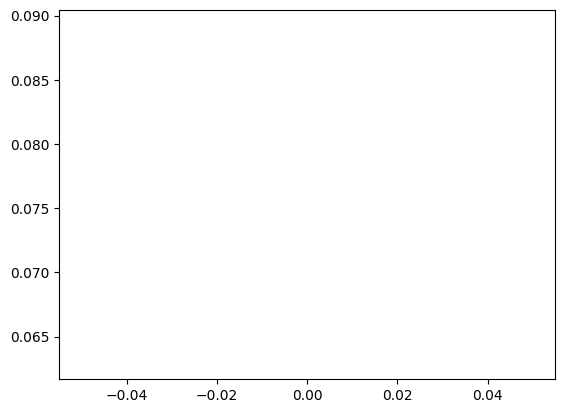

In [26]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

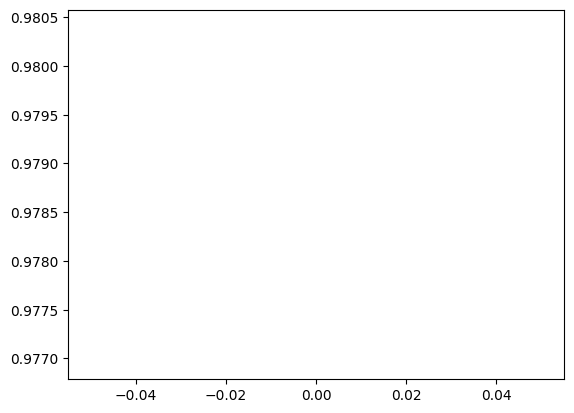

In [27]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])

In [28]:
# 11

In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 64)        │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │       3,211,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 30)                  │           1,950 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,329,118 (12.70 MB)

 Trainable params: 3,329,118 (12.70 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
audio_path = "left.wav"

signal, sr = librosa.load(audio_path, sr=16000)

signal = signal[:16000]

mel_spec = librosa.feature.melspectrogram(
    y=signal,
    sr=sr,
    n_mels=128,
    hop_length=512,
    n_fft=2048
)

mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

voice_array = pad_spectrogram(mel_spec_db)

voice_array = voice_array.reshape(1,128,128,1)

In [45]:
pred = model.predict(voice_array)

reverse_labels = {v:k for k,v in labels.items()}

print(reverse_labels[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
nine


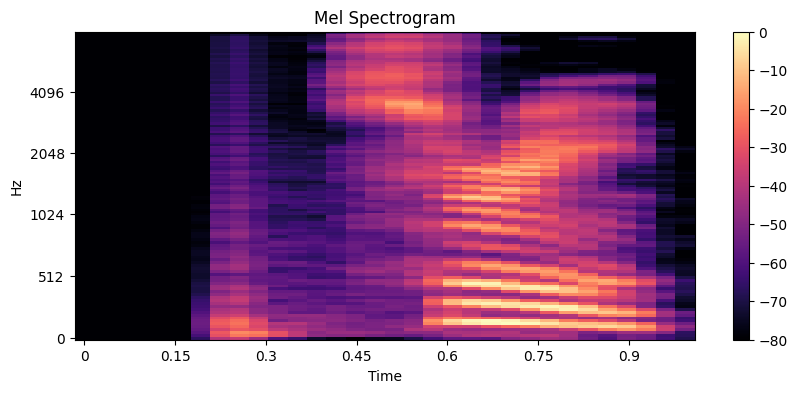

In [30]:
plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='mel'
)

plt.title("Mel Spectrogram")
plt.colorbar()
plt.show()